In [1]:
!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
    -O /content/Data/cats_and_dogs_filtered.zip

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
local_zip = r"C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\2024 Deep Learning\cats_and_dogs.zip"
zipref = zipfile.ZipFile(local_zip)
zipref.extractall(r"C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content")

In [4]:
os.listdir(r"C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages")

['Cat', 'Dog']

In [ ]:
# print(os.listdir('/content/Data/cats_and_dogs_filtered/train'))
# print(os.listdir('/content/Data/cats_and_dogs_filtered/validation'))

['dogs', 'cats']
['dogs', 'cats']


In [10]:
print(os.listdir(r'C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Dog')[:10])
print(os.listdir(r'C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Cat')[:10])

['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg']
['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg']


In [11]:
base_dir = r'C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages'

cats_dir = os.path.join(base_dir, 'Cat')
dogs_dir = os.path.join(base_dir, 'Dog')

print(cats_dir)
print(dogs_dir)

print('Number of cat images:', len(os.listdir(cats_dir)))
print('Number of dog images:', len(os.listdir(dogs_dir)))

C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Cat
C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Dog
Number of cat images: 12501
Number of dog images: 12501


(np.float64(-0.5), np.float64(499.5), np.float64(374.5), np.float64(-0.5))

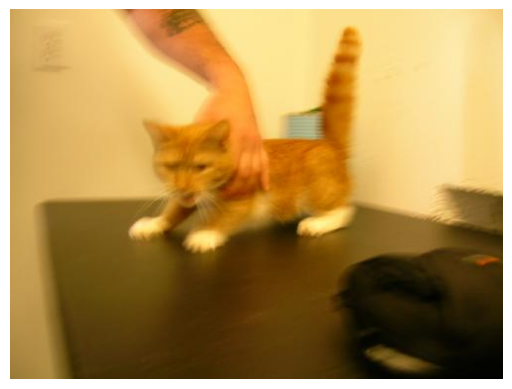

In [12]:
# Accessing and visualising a cat image
cat_image_path = os.path.join(r'C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Cat','0.jpg')
cat_image = mpimg.imread(cat_image_path)
plt.imshow(cat_image)
plt.axis('off')

(np.float64(-0.5), np.float64(499.5), np.float64(374.5), np.float64(-0.5))

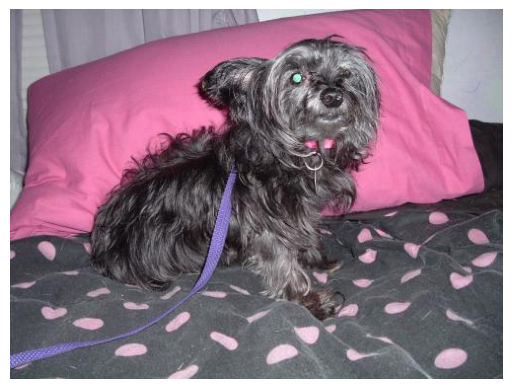

In [13]:
# Accessing and visualising a dog image
dog_image_path = os.path.join(r'C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Dog', '0.jpg')
dog_image = mpimg.imread(dog_image_path)
plt.imshow(dog_image)
plt.axis('off')

In [15]:
def create_paths(n = 20, dir = r'C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages'):
  cats_dir = os.path.join(dir, 'Cat')
  dogs_dir = os.path.join(dir, 'Dog')
  cat_images = os.listdir(cats_dir)[:n]
  dog_images = os.listdir(dogs_dir)[:n]

  cat_image_paths = [os.path.join(cats_dir, image) for image in cat_images]
  dog_image_paths = [os.path.join(dogs_dir, image) for image in dog_images]

  image_paths = cat_image_paths + dog_image_paths
  return image_paths

create_paths(n = 2)

['C:\\Rehan\\tut\\Python\\Introduction-to-Python-for-Data-Sciences\\DPCOE\\DL\\Notes\\2024 Deep Learning -20260221T155208Z-1-001\\content\\PetImages\\Cat\\0.jpg',
 'C:\\Rehan\\tut\\Python\\Introduction-to-Python-for-Data-Sciences\\DPCOE\\DL\\Notes\\2024 Deep Learning -20260221T155208Z-1-001\\content\\PetImages\\Cat\\1.jpg',
 'C:\\Rehan\\tut\\Python\\Introduction-to-Python-for-Data-Sciences\\DPCOE\\DL\\Notes\\2024 Deep Learning -20260221T155208Z-1-001\\content\\PetImages\\Dog\\0.jpg',
 'C:\\Rehan\\tut\\Python\\Introduction-to-Python-for-Data-Sciences\\DPCOE\\DL\\Notes\\2024 Deep Learning -20260221T155208Z-1-001\\content\\PetImages\\Dog\\1.jpg']

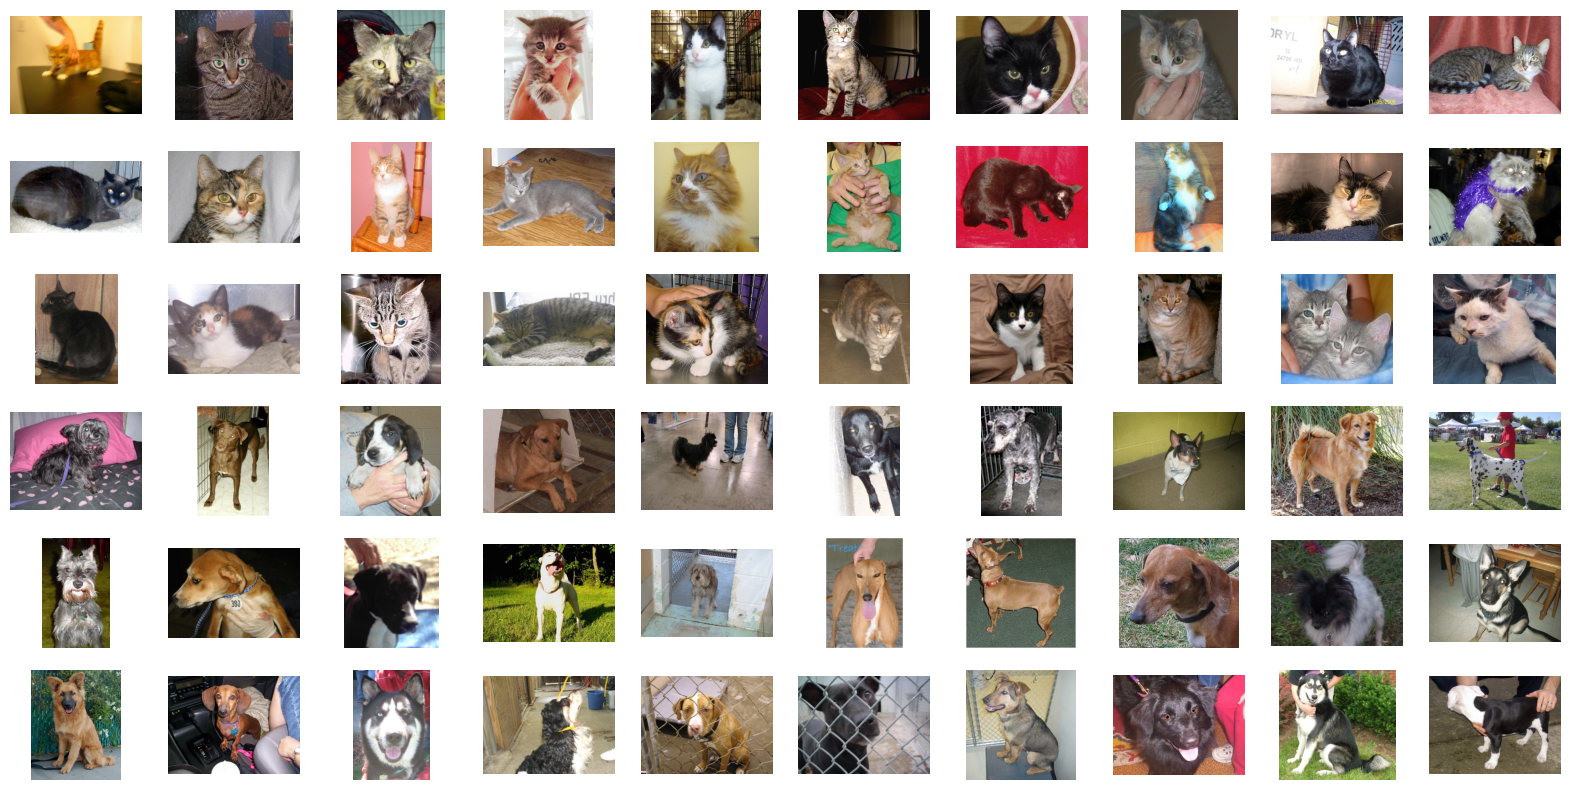

In [16]:
image_paths = create_paths(30)

plt.figure(figsize = (20,10))
for i in range(60):
  plt.subplot(6, 10, i+1)
  image = mpimg.imread(image_paths[i])
  plt.imshow(image)
  plt.axis('off')

In [24]:
import os
from PIL import Image

def clean_corrupted_images(folder_path):
    removed = 0
    for folder in os.listdir(folder_path):
        folder_full = os.path.join(folder_path, folder)
        if os.path.isdir(folder_full):
            for filename in os.listdir(folder_full):
                filepath = os.path.join(folder_full, filename)
                try:
                    img = Image.open(filepath)
                    img.verify()   # check if image is valid
                except Exception:
                    print(f"Removing corrupted: {filepath}")
                    os.remove(filepath)
                    removed += 1
    print(f"Done! Removed {removed} corrupted images")

# Run this BEFORE creating generators
clean_corrupted_images(base_dir)

Removing corrupted: C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Cat\666.jpg
Removing corrupted: C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Cat\Thumbs.db
Removing corrupted: C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Dog\11702.jpg
Removing corrupted: C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\DL\Notes\2024 Deep Learning -20260221T155208Z-1-001\content\PetImages\Dog\Thumbs.db
Done! Removed 4 corrupted images


In [25]:
train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=40,        # changed 0.1 → 40 degrees
    zoom_range=0.2,           # changed 0.1 → 0.2
    width_shift_range=0.2,    # changed 0.1 → 0.2
    height_shift_range=0.2,   # changed 0.1 → 0.2
    shear_range=0.2,          # changed 0.1 → 0.2
    horizontal_flip=True,
    validation_split=0.2      # added — creates validation automatically
    # removed vertical_flip → not natural for cats/dogs
)

train_generator = train_datagen.flow_from_directory(
    base_dir,                 
    batch_size=50,
    target_size=(150,150),
    class_mode='binary',
    subset='training'         # added — takes 80% for training
)


Found 20000 images belonging to 2 classes.


In [26]:
val_datagen = ImageDataGenerator(
    rescale=1/255,
    validation_split=0.2      # added — must match train_datagen
)

val_generator = val_datagen.flow_from_directory(
    base_dir,                 
    target_size=(150,150),
    batch_size=50,
    class_mode='binary',
    subset='validation'       # added — takes 20% for validation
)

Found 4998 images belonging to 2 classes.


In [27]:
model = tf.keras.models.Sequential()

model.add(Flatten(input_shape = (150,150,3)))
model.add(Dense(1024, activation = 'relu'))
model.add(Dense(1024, activation = 'relu'))
model.add(Dense(512, activation = 'relu'))
model.add(Dense(256, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │    69,121,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,827,009 (270.18 MB)

 Trainable params: 70,827,009 (270.18 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss = 'binary_crossentropy',
              optimizer = SGD(),
              metrics = ['accuracy'])

In [29]:
history = model.fit(
    train_generator,
    validation_data = (val_generator),
    epochs = 20,
    verbose = 1
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 106s 265ms/step - accuracy: 0.5520 - loss: 0.6878 - val_accuracy: 0.5998 - val_loss: 0.6670
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 98s 245ms/step - accuracy: 0.5716 - loss: 0.6802 - val_accuracy: 0.6030 - val_loss: 0.6648
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 103s 257ms/step - accuracy: 0.5791 - loss: 0.6739 - val_accuracy: 0.6072 - val_loss: 0.6569
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 95s 237ms/step - accuracy: 0.5877 - loss: 0.6707 - val_accuracy: 0.6082 - val_loss: 0.6579
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 102s 256ms/step - accuracy: 0.5846 - loss: 0.6688 - val_accuracy: 0.6146 - val_loss: 0.6537
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 101s 252ms/step - accuracy: 0.5921 - loss: 0.6675 - val_accuracy: 0.6214 - val_loss: 0.6476
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 106s 265ms/step - accuracy: 0.5925 - loss: 0.6645 - val_accuracy: 0.6028 - val_loss: 0.6569
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 99s 247ms/step - accuracy: 0.5948 - lo

In [30]:
acc_train = history.history['accuracy']
acc_val   = history.history['val_accuracy']

loss_train = history.history['loss']
loss_val   = history.history['val_loss']

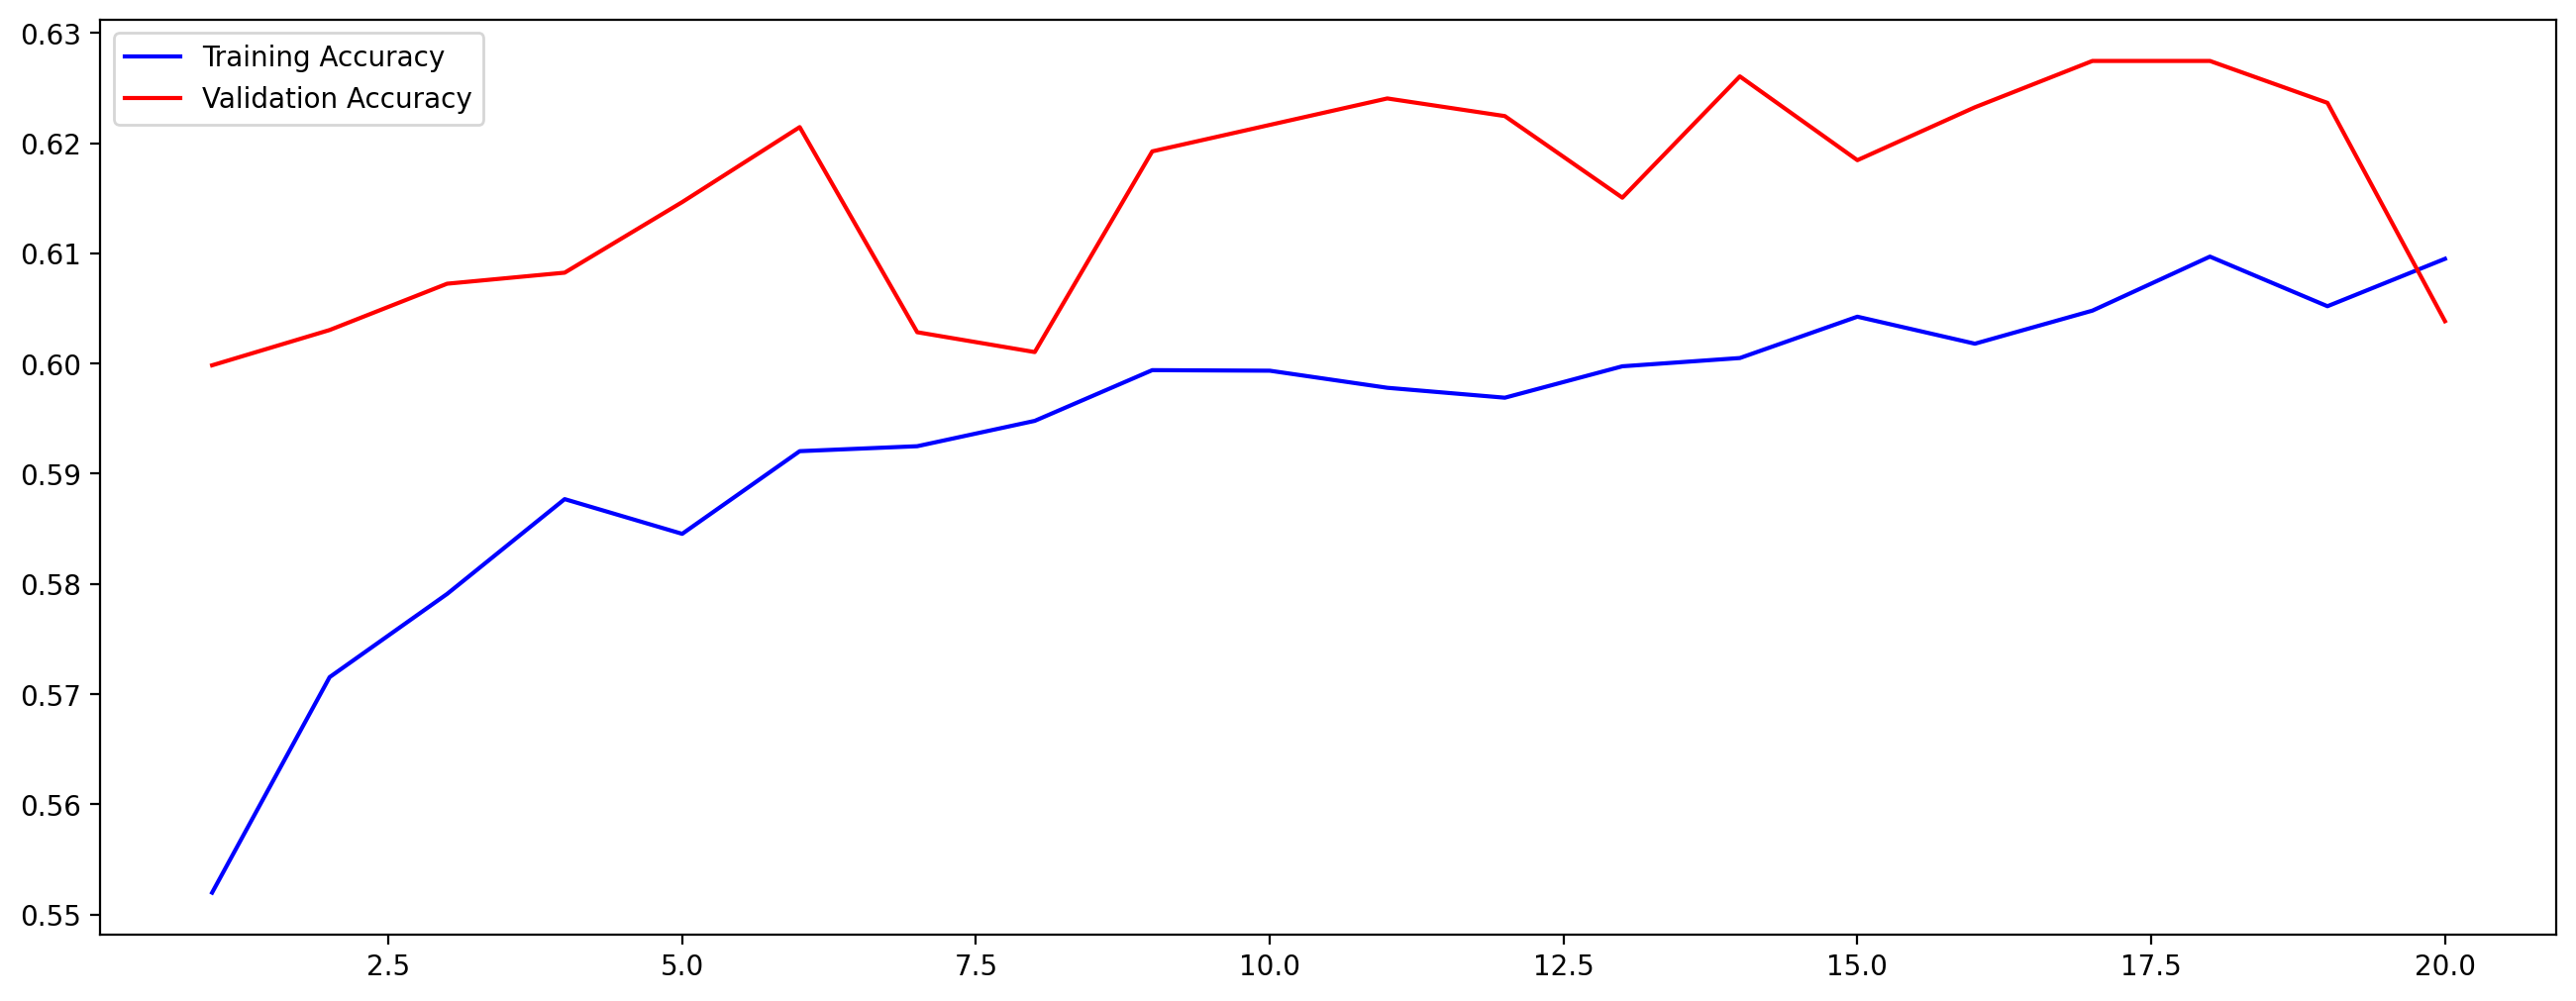

In [ ]:
num_epochs = range(1,21)

plt.figure(figsize  =(16,6), dpi = 200)
plt.plot(num_epochs, acc_train, c = 'blue', label = 'Training Accuracy')
plt.plot(num_epochs, acc_val, c = 'red', label = 'Validation Accuracy')
plt.legend()
plt.show()

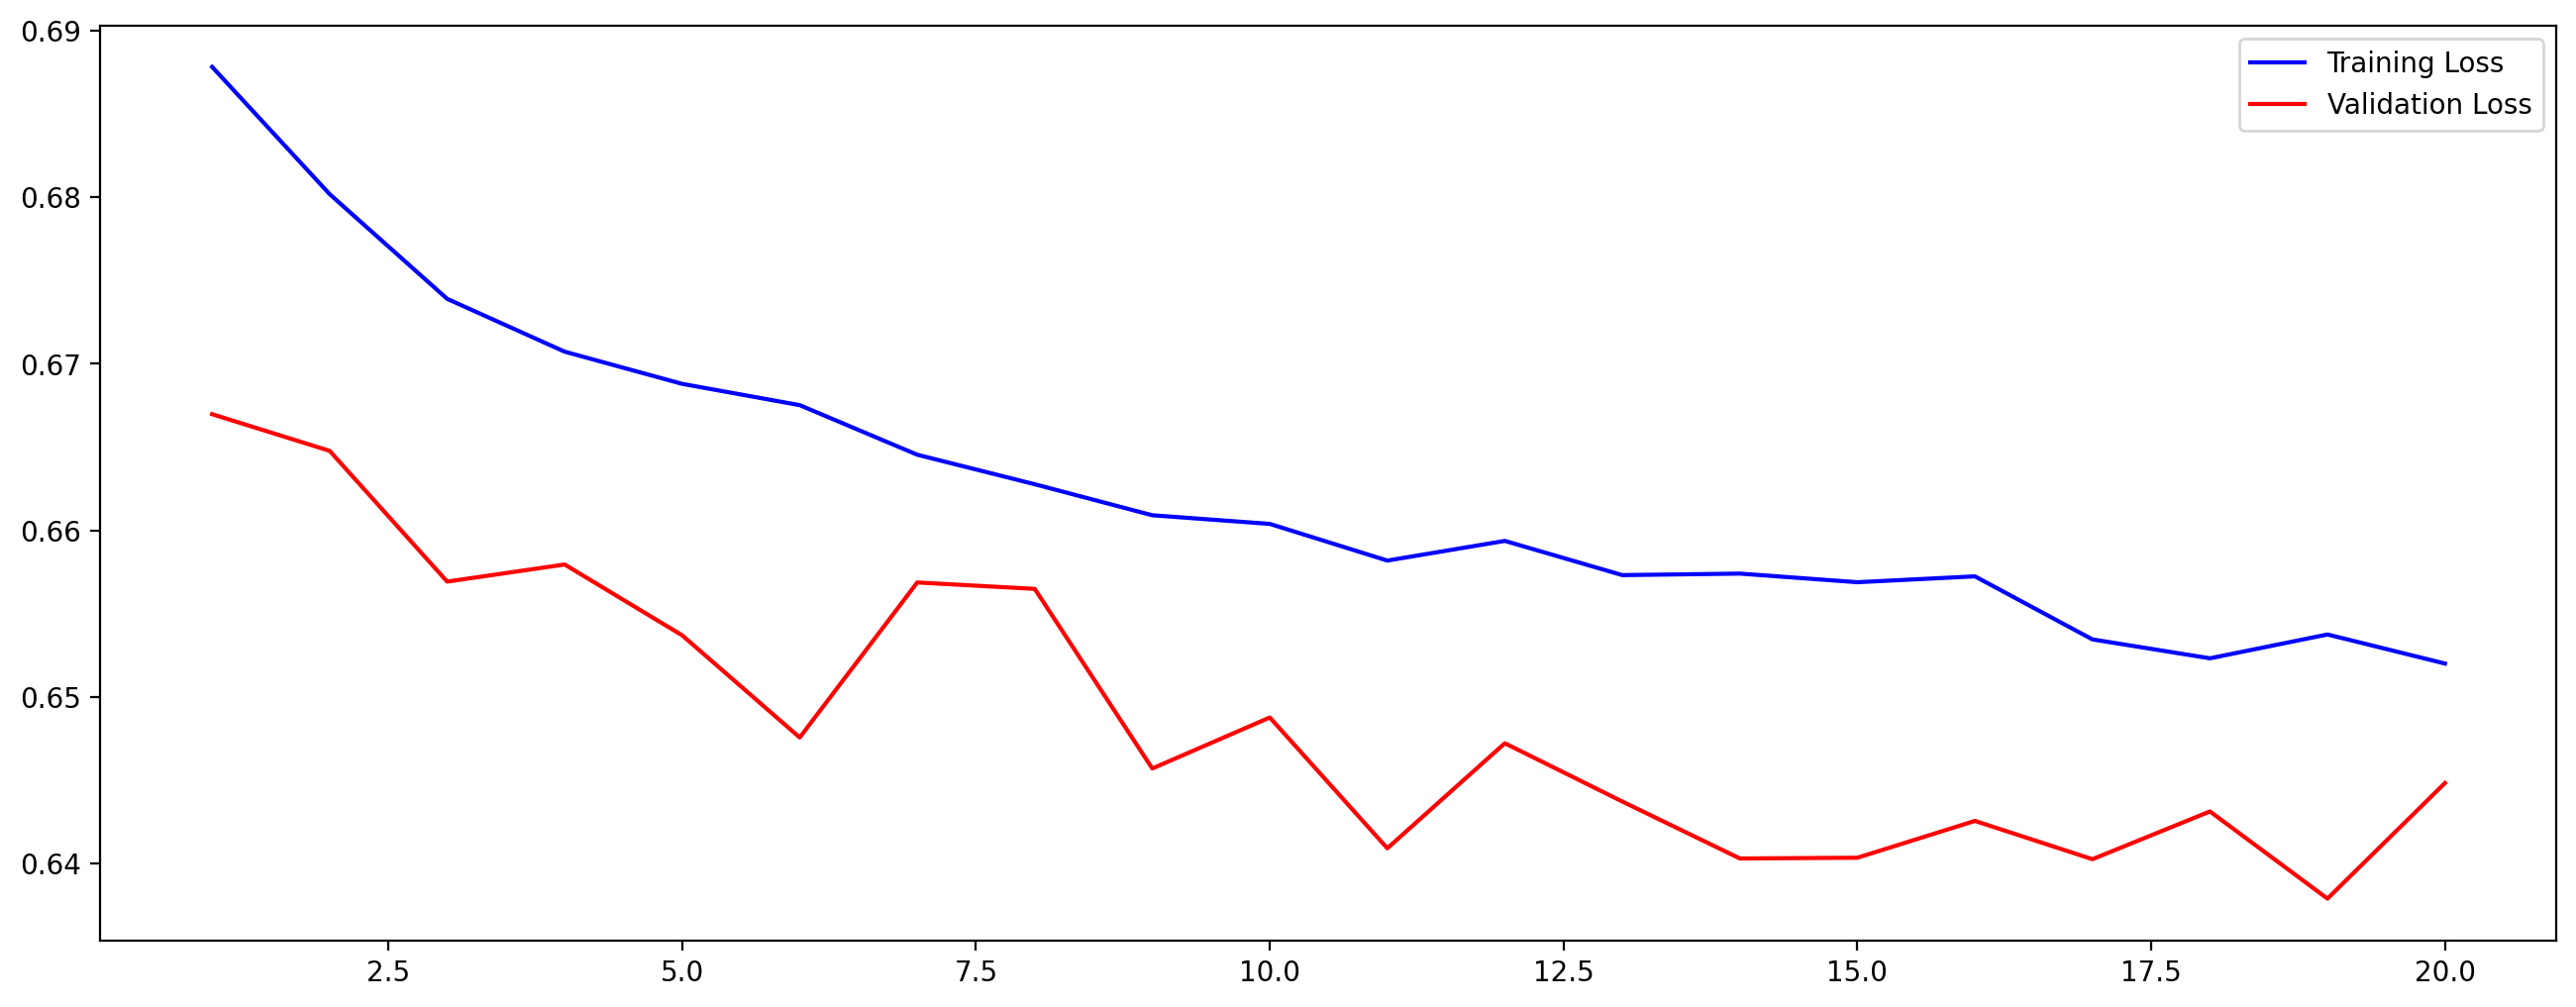

In [33]:
plt.figure(figsize  =(16,6), dpi = 200)
plt.plot(num_epochs, loss_train, c = 'blue', label = 'Training Loss')
plt.plot(num_epochs, loss_val, c = 'red', label = 'Validation Loss')
plt.legend()
plt.show()

In [38]:
import cv2

def read_image(path):
  image = mpimg.imread(path)
  image = cv2.resize(image, (150,150))
  image = image.reshape(1,150,150,3)
  image = image / 255
  return image

In [45]:
def make_prediction(image):
  result = model.predict(image)
  if result > 0.5:
    print('The image is a dog')
  else:
    print('the image is a cat')

In [48]:
img = read_image('/content/Data/cats_and_dogs_filtered/train/cats/cat.120.jpg')
make_prediction(img)

1/1 [==============================] - 0s 17ms/step
the image is a cat
